Dataset Info:
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset shape: (200, 5)

Column names: ['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Data types:
CustomerID                 int64
Genre                     object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

Missing values:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Basic statistics:
       CustomerID         Age  Annual Income (k$)  Spending 

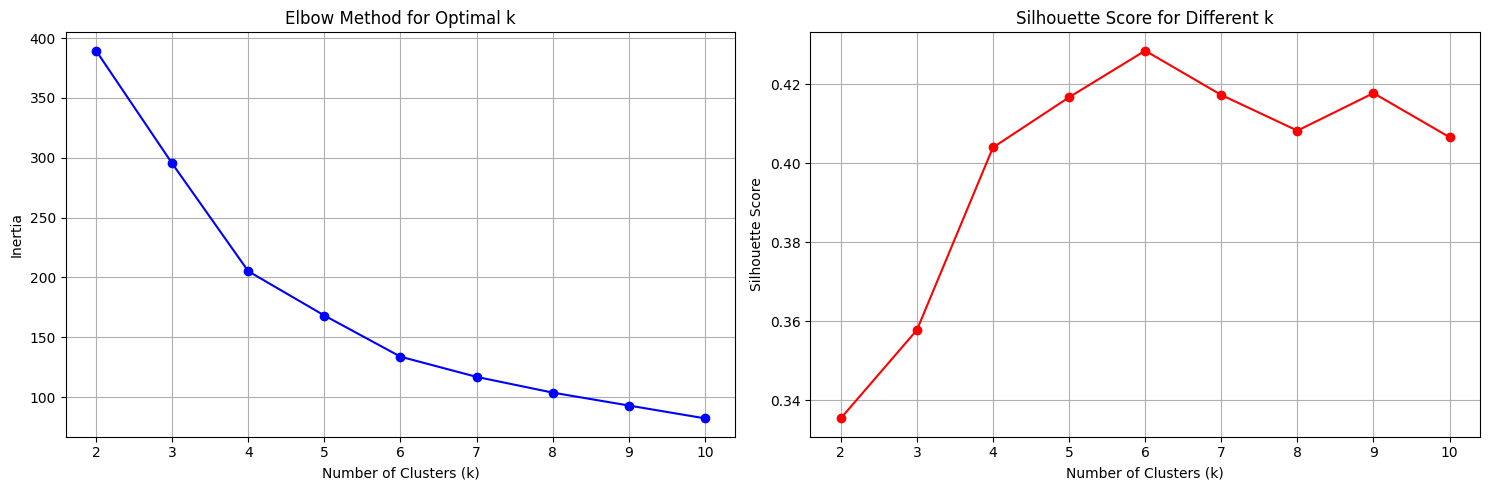


Silhouette Scores:
k=2: 0.335
k=3: 0.358
k=4: 0.404
k=5: 0.417
k=6: 0.428
k=7: 0.417
k=8: 0.408
k=9: 0.418
k=10: 0.407

Using k=5 clusters

Cluster Distribution:
Cluster
0    20
1    54
2    40
3    39
4    47
Name: count, dtype: int64

Cluster Statistics:
           Age        Annual Income (k$)        Spending Score (1-100)       
          mean    std               mean    std                   mean    std
Cluster                                                                      
0        46.25  11.58              26.75   7.31                  18.35  11.94
1        25.19   5.51              41.09  16.82                  62.24  16.60
2        32.88   3.86              86.10  16.34                  81.53  10.00
3        39.87  10.94              86.10  16.73                  19.36  11.61
4        55.64   8.91              54.38   8.82                  48.85   6.30


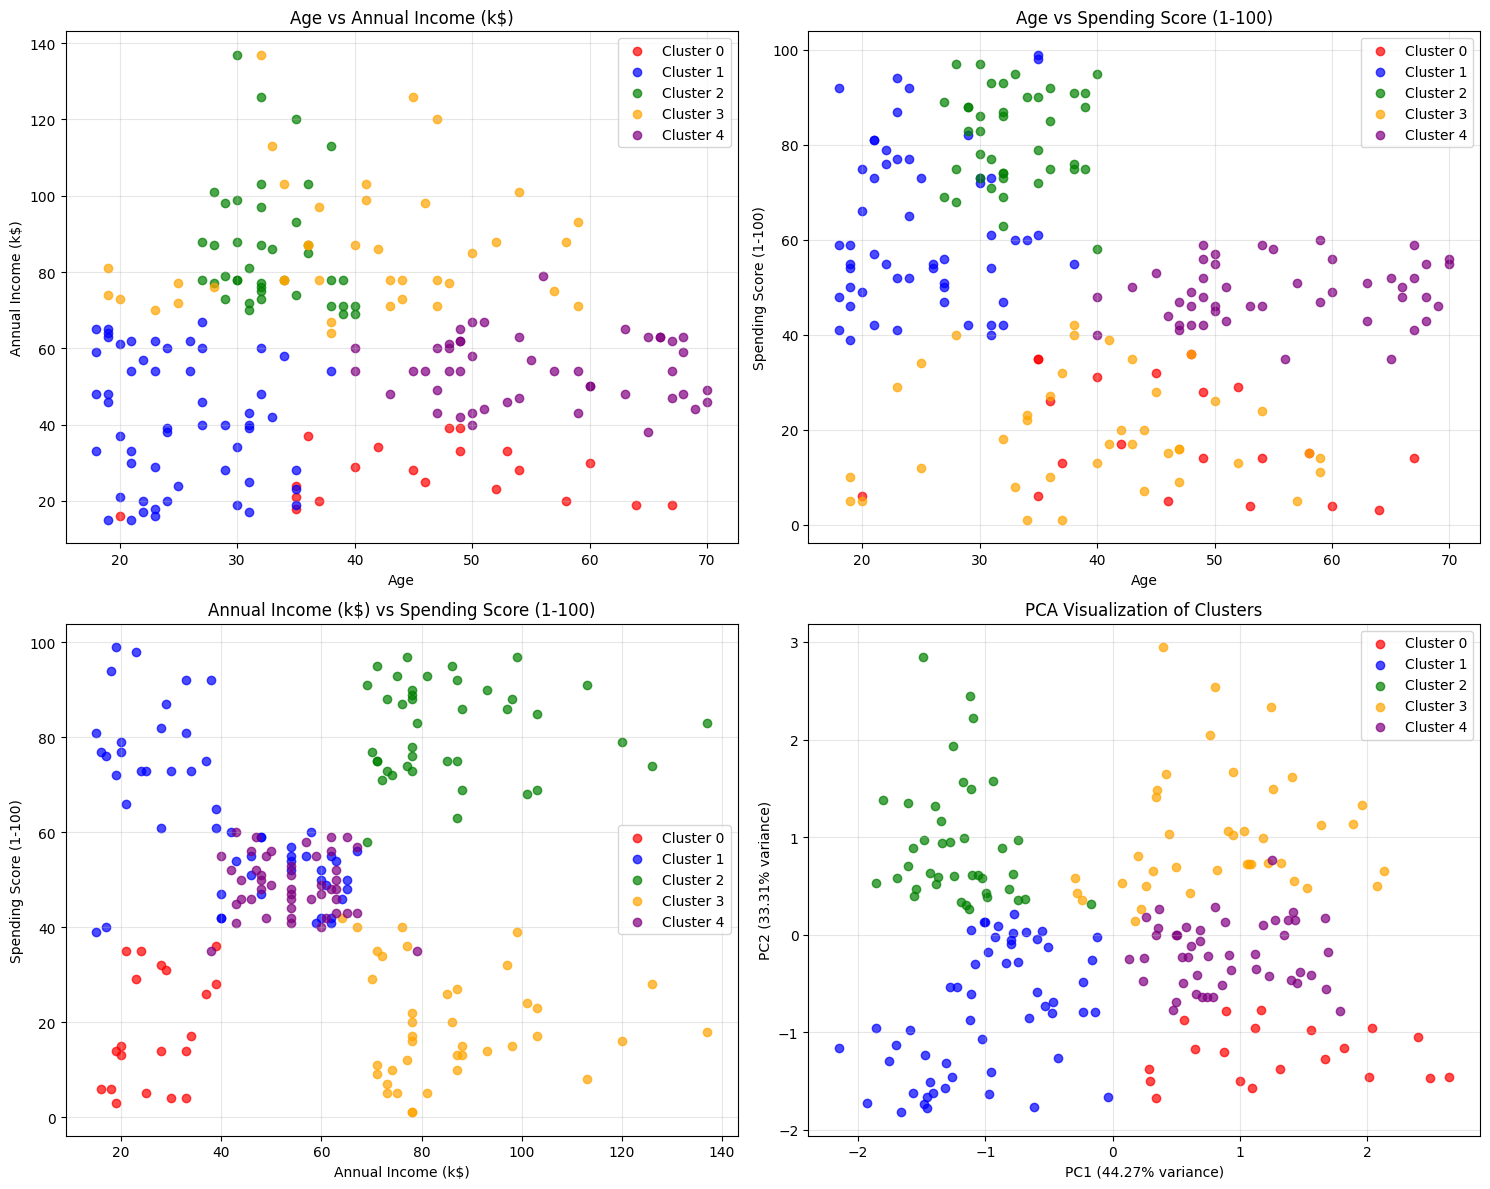


Detailed Cluster Analysis:

--- Cluster 0 ---
Size: 20 customers (10.0%)
Gender distribution: {'Female': 12, 'Male': 8}
Age: 46.2 ± 11.6
Annual Income: $26.8k ± 7.3k
Spending Score: 18.4 ± 11.9

--- Cluster 1 ---
Size: 54 customers (27.0%)
Gender distribution: {'Female': 32, 'Male': 22}
Age: 25.2 ± 5.5
Annual Income: $41.1k ± 16.8k
Spending Score: 62.2 ± 16.6

--- Cluster 2 ---
Size: 40 customers (20.0%)
Gender distribution: {'Female': 22, 'Male': 18}
Age: 32.9 ± 3.9
Annual Income: $86.1k ± 16.3k
Spending Score: 81.5 ± 10.0

--- Cluster 3 ---
Size: 39 customers (19.5%)
Gender distribution: {'Male': 20, 'Female': 19}
Age: 39.9 ± 10.9
Annual Income: $86.1k ± 16.7k
Spending Score: 19.4 ± 11.6

--- Cluster 4 ---
Size: 47 customers (23.5%)
Gender distribution: {'Female': 27, 'Male': 20}
Age: 55.6 ± 8.9
Annual Income: $54.4k ± 8.8k
Spending Score: 48.9 ± 6.3

CLUSTER INTERPRETATION

Clustered data saved to 'clustered_customers.csv'
Final model silhouette score: 0.417


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Load the data
df = pd.read_csv('/Users/hemang/Downloads/Mall_Customers.csv')

# Display basic info about the dataset
print("Dataset Info:")
print(df.head())
print(f"\nDataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")

# Check for missing values
print(f"\nMissing values:\n{df.isnull().sum()}")

# Basic statistics
print(f"\nBasic statistics:")
print(df.describe())

# Prepare features for clustering
# We'll use Age, Annual Income, and Spending Score for clustering
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features].copy()

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Find optimal number of clusters using elbow method
def find_optimal_clusters(X, max_k=10):
    """Find optimal number of clusters using elbow method and silhouette score"""
    inertias = []
    silhouette_scores = []
    k_range = range(2, max_k + 1)
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X)
        inertias.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(X, kmeans.labels_))
    
    return k_range, inertias, silhouette_scores

# Find optimal clusters
k_range, inertias, silhouette_scores = find_optimal_clusters(X_scaled)

# Plot elbow curve and silhouette scores
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Elbow curve
ax1.plot(k_range, inertias, 'bo-')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method for Optimal k')
ax1.grid(True)

# Silhouette scores
ax2.plot(k_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score for Different k')
ax2.grid(True)

plt.tight_layout()
plt.show()

# Print silhouette scores for reference
print("\nSilhouette Scores:")
for k, score in zip(k_range, silhouette_scores):
    print(f"k={k}: {score:.3f}")

# Based on analysis, let's use k=5 clusters (you can adjust this)
optimal_k = 5
print(f"\nUsing k={optimal_k} clusters")

# Perform K-means clustering
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to the original dataframe
df['Cluster'] = cluster_labels

# Display cluster statistics
print(f"\nCluster Distribution:")
print(df['Cluster'].value_counts().sort_index())

print(f"\nCluster Statistics:")
cluster_stats = df.groupby('Cluster')[features].agg(['mean', 'std']).round(2)
print(cluster_stats)

# Visualize clusters
def plot_clusters(df, features, cluster_col='Cluster'):
    """Create comprehensive cluster visualizations"""
    n_features = len(features)
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 2D scatter plots for different feature combinations
    feature_pairs = [
        ('Age', 'Annual Income (k$)'),
        ('Age', 'Spending Score (1-100)'),
        ('Annual Income (k$)', 'Spending Score (1-100)'),
        ('Age', 'Annual Income (k$)')  # This will be replaced with PCA
    ]
    
    colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']
    
    for i, (feat1, feat2) in enumerate(feature_pairs[:3]):
        ax = axes[i//2, i%2]
        for cluster in sorted(df[cluster_col].unique()):
            cluster_data = df[df[cluster_col] == cluster]
            ax.scatter(cluster_data[feat1], cluster_data[feat2], 
                      c=colors[cluster], label=f'Cluster {cluster}', alpha=0.7)
        
        ax.set_xlabel(feat1)
        ax.set_ylabel(feat2)
        ax.set_title(f'{feat1} vs {feat2}')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # PCA visualization
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    ax = axes[1, 1]
    for cluster in sorted(df[cluster_col].unique()):
        mask = df[cluster_col] == cluster
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                  c=colors[cluster], label=f'Cluster {cluster}', alpha=0.7)
    
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
    ax.set_title('PCA Visualization of Clusters')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Create visualizations
plot_clusters(df, features)

# Analyze cluster characteristics
print(f"\nDetailed Cluster Analysis:")
for cluster in sorted(df['Cluster'].unique()):
    cluster_data = df[df['Cluster'] == cluster]
    print(f"\n--- Cluster {cluster} ---")
    print(f"Size: {len(cluster_data)} customers ({len(cluster_data)/len(df)*100:.1f}%)")
    print(f"Gender distribution: {cluster_data['Genre'].value_counts().to_dict()}")
    print(f"Age: {cluster_data['Age'].mean():.1f} ± {cluster_data['Age'].std():.1f}")
    print(f"Annual Income: ${cluster_data['Annual Income (k$)'].mean():.1f}k ± {cluster_data['Annual Income (k$)'].std():.1f}k")
    print(f"Spending Score: {cluster_data['Spending Score (1-100)'].mean():.1f} ± {cluster_data['Spending Score (1-100)'].std():.1f}")

# Create a summary interpretation
print(f"\n" + "="*50)
print("CLUSTER INTERPRETATION")
print("="*50)

cluster_interpretations = {
    0: "Analyze the characteristics to provide interpretation",
    1: "Analyze the characteristics to provide interpretation",
    2: "Analyze the characteristics to provide interpretation",
    3: "Analyze the characteristics to provide interpretation",
    4: "Analyze the characteristics to provide interpretation"
}

# Save results to CSV
df.to_csv('clustered_customers.csv', index=False)
print(f"\nClustered data saved to 'clustered_customers.csv'")

# Display final silhouette score for chosen model
final_silhouette = silhouette_score(X_scaled, cluster_labels)
print(f"Final model silhouette score: {final_silhouette:.3f}")